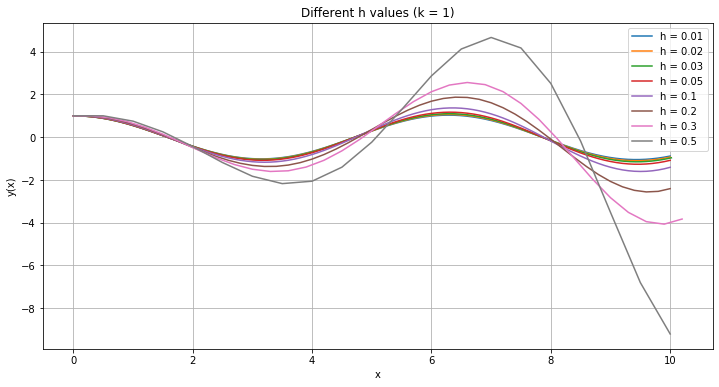

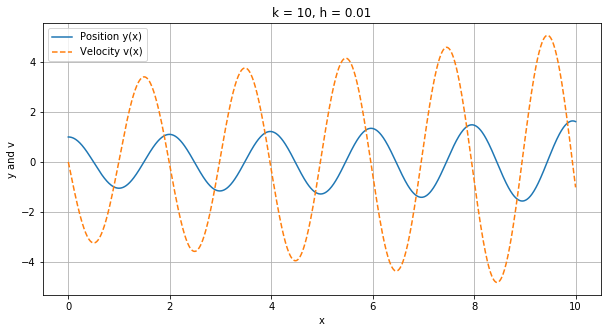

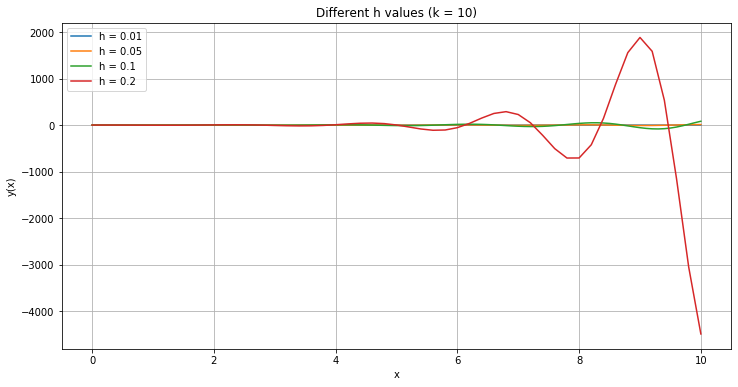

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# function so I don't repeat the same code 10 times
def euler_solver(k, h, x_start, x_end, y_0, v_0):
    x_values = np.arange(x_start, x_end + h, h)
    y_values = np.zeros(len(x_values))
    v_values = np.zeros(len(x_values))

    # initial conditions
    y_values[0] = y_0
    v_values[0] = v_0

    # Euler's Method
    for i in range(1, len(x_values)):
        y_n = y_values[i - 1]
        v_n = v_values[i - 1]

        # from system: y' = v, v' = -k*y
        y_values[i] = y_n + h * v_n
        v_values[i] = v_n + h * (-k * y_n)

    return x_values, y_values, v_values


# Part 1: test different h (k = 1)
k = 1.0
x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0

h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]

plt.figure(figsize=(12, 6))

for h in h_values:
    x, y, v = euler_solver(k, h, x_start, x_end, y_0, v_0)
    plt.plot(x, y, label=f'h = {h}')

plt.title("Different h values (k = 1)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True)
plt.show()


# Part 2: single case (k = 10)
k = 10.0
h = 0.01

x, y, v = euler_solver(k, h, x_start, x_end, y_0, v_0)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Position y(x)')
plt.plot(x, v, '--', label='Velocity v(x)')
plt.title("k = 10, h = 0.01")
plt.xlabel("x")
plt.ylabel("y and v")
plt.legend()
plt.grid(True)
plt.show()


# Part 3: multiple h for k = 10 (this shows instability clearly)
k = 10.0
h_values_k10 = [0.01, 0.05, 0.1, 0.2]

plt.figure(figsize=(12, 6))

for h in h_values_k10:
    x, y, v = euler_solver(k, h, x_start, x_end, y_0, v_0)
    plt.plot(x, y, label=f'h = {h}')

plt.title("Different h values (k = 10)")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True)
plt.show()

## When does it become unstable?
Euler’s Method is unstable for this oscillation problem for any positive step size. However, when the step size is very small, like 0.01, the instability happens more slowly, so the graph may look fine at first. As the step size gets larger, the instability becomes much more obvious because the amplitude grows faster instead of staying constant.

## Is it becoming unstable?
Yes, it is becoming unstable. You can tell because the oscillations should stay about the same size, but instead they get bigger over time. This means Euler’s Method is adding numerical error and causing the solution to drift away from the true answer.

## Play with the value of k, what are you seeing?
When I increase k, the solution oscillates faster. This means the graph changes more quickly, so Euler’s Method has a harder time following it accurately. As k gets larger, the numerical error becomes more noticeable unless the step size is made smaller.

## Set k = 10, h = 0.01
When I set k=10 and h=0.01, the graph oscillates much faster than when k=1. Even though the step size is small, the amplitude still slowly grows over time, which shows that Euler’s Method is still introducing instability.

## Thoughts on whether Euler’s Method can solve this with a larger h?
Euler’s Method is not a very good choice for this problem when h is larger. A larger step size makes the numerical error grow faster, so the solution becomes unstable much sooner. It can still produce a graph, but it is not very accurate or reliable for oscillating equations unless the step size is very small.